# Binary Classification on Customer Churn using Keras

## By: Ayush Trivedi

### Importing Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import confusion_matrix

### Data Loading and Understanding

In [2]:
df=pd.read_csv(r"C:\Users\ayush\Downloads\Customer Churn\customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Manipulation

In [8]:
df[(df["gender"]=="Male")]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
df[(df["InternetService"]=="DSL")]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No


In [10]:
new_customer=df[(df["gender"]=="Female") & (df["SeniorCitizen"]==1) & (df["PaymentMethod"]=="Mailed check")]

In [11]:
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,Yes
176,2656-FMOKZ,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.45,1145.7,Yes
267,3197-ARFOY,Female,1,No,No,19,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,105.00,2007.25,No
451,5760-WRAHC,Female,1,No,No,22,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.75,1545.4,No
470,4933-IKULF,Female,1,No,No,17,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,330.6,No


In [12]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [14]:
new_customer=df[(df['tenure']<10.00) | (df['TotalCharges']<500.00)]
new_customer.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


### Data Visualization

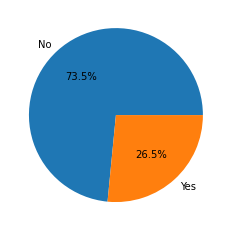

In [15]:
x=df["Churn"].value_counts().keys().tolist()
y=df["Churn"].value_counts()
plt.pie(y,labels=x,autopct="%0.1f%%")
plt.show()

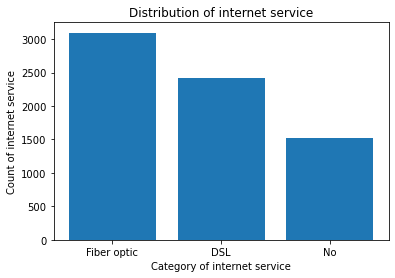

In [16]:
x=df["InternetService"].value_counts().keys().tolist()
y=df["InternetService"].value_counts()
plt.bar(x,y,width=0.8)
plt.xlabel("Category of internet service")
plt.ylabel("Count of internet service")
plt.title("Distribution of internet service")
plt.show()

### Model Building

In [18]:
x=df.loc[:,["tenure"]].values
y=df.loc[:,["Churn"]].values

In [20]:
le=LabelEncoder()
y=le.fit_transform(y)

C:\Users\ayush\anaconda3\lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [21]:
(x_train,x_test,y_train,y_test)=train_test_split(x,y,test_size=0.3,random_state=42)

In [23]:
x_train.shape

(4930, 1)

In [24]:
y_train.shape

(4930,)

In [26]:
model = Sequential()
model.add(Dense(128, input_dim=1, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               256       
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 8,577
Trainable params: 8,577
Non-trainable params: 0
_________________________________________________________________


In [28]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=["acc"])

In [29]:
model.fit(x=x_train, y=y_train, epochs=150, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/150
155/155 [==============================] - 1s 4ms/step - loss: 0.5135 - acc: 0.7371 - val_loss: 0.5130 - val_acc: 0.7269
Epoch 2/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5146 - acc: 0.7357 - val_loss: 0.5129 - val_acc: 0.7283
Epoch 3/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5147 - acc: 0.7373 - val_loss: 0.5241 - val_acc: 0.7283
Epoch 4/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5148 - acc: 0.7371 - val_loss: 0.5218 - val_acc: 0.7283
Epoch 5/150
155/155 [==============================] - 0s 3ms/step - loss: 0.5135 - acc: 0.7363 - val_loss: 0.5113 - val_acc: 0.7269
Epoch 6/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5140 - acc: 0.7357 - val_loss: 0.5278 - val_acc: 0.7283
Epoch 7/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5146 - acc: 0.7363 - val_loss: 0.5131 - val_acc: 0.7269
Epoch 8/150
155/155 [==============================] - 0s 2ms/step - 

155/155 [==============================] - 0s 2ms/step - loss: 0.5141 - acc: 0.7373 - val_loss: 0.5127 - val_acc: 0.7283
Epoch 63/150
155/155 [==============================] - 0s 3ms/step - loss: 0.5143 - acc: 0.7371 - val_loss: 0.9628 - val_acc: 0.2717
Epoch 64/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5168 - acc: 0.7345 - val_loss: 0.5164 - val_acc: 0.7283
Epoch 65/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5136 - acc: 0.7373 - val_loss: 0.5292 - val_acc: 0.7283
Epoch 66/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5153 - acc: 0.7373 - val_loss: 0.5246 - val_acc: 0.7283
Epoch 67/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5138 - acc: 0.7373 - val_loss: 0.5101 - val_acc: 0.7283
Epoch 68/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5143 - acc: 0.7373 - val_loss: 0.5130 - val_acc: 0.7283
Epoch 69/150
155/155 [==============================] - 0s 2ms/step - loss:

155/155 [==============================] - 0s 2ms/step - loss: 0.5162 - acc: 0.7357 - val_loss: 0.5108 - val_acc: 0.7283
Epoch 124/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5136 - acc: 0.7373 - val_loss: 0.5222 - val_acc: 0.7283
Epoch 125/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5147 - acc: 0.7373 - val_loss: 0.5124 - val_acc: 0.7283
Epoch 126/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5135 - acc: 0.7373 - val_loss: 0.5192 - val_acc: 0.7283
Epoch 127/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5132 - acc: 0.7373 - val_loss: 0.5111 - val_acc: 0.7283
Epoch 128/150
155/155 [==============================] - 1s 3ms/step - loss: 0.5129 - acc: 0.7373 - val_loss: 0.5289 - val_acc: 0.7283
Epoch 129/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5124 - acc: 0.7373 - val_loss: 0.5182 - val_acc: 0.7283
Epoch 130/150
155/155 [==============================] - 0s 2ms/step 

In [30]:
np.mean(model.history.history['val_acc'])

0.706950618426005

In [31]:
lst1=model.history.history["acc"]
lst2=model.history.history["val_acc"]

In [32]:
y_pred=model.predict(x_test)

67/67 [==============================] - 0s 968us/step


In [33]:
y_pred=np.where(y_pred>0.5,1,0)

In [35]:
confusion_matrix(y_test,y_pred)

array([[1539,    0],
       [ 574,    0]], dtype=int64)

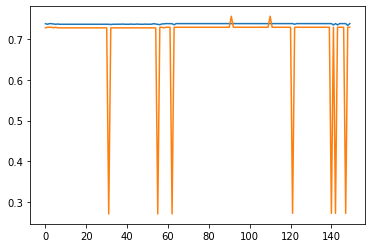

In [36]:
plt.plot(lst1)
plt.plot(lst2)
plt.show()

In [38]:
model.add(Dense(12, input_dim=1, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

In [39]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=["acc"])

In [40]:
model.fit(x=x_train, y=y_train, epochs=150, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/150
155/155 [==============================] - 1s 3ms/step - loss: 0.6752 - acc: 0.7142 - val_loss: 0.6596 - val_acc: 0.7283
Epoch 2/150
155/155 [==============================] - 0s 3ms/step - loss: 0.6441 - acc: 0.7375 - val_loss: 0.6325 - val_acc: 0.7283
Epoch 3/150
155/155 [==============================] - 0s 2ms/step - loss: 0.6176 - acc: 0.7369 - val_loss: 0.6081 - val_acc: 0.7283
Epoch 4/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5977 - acc: 0.7367 - val_loss: 0.5914 - val_acc: 0.7283
Epoch 5/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5845 - acc: 0.7369 - val_loss: 0.5820 - val_acc: 0.7283
Epoch 6/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5761 - acc: 0.7373 - val_loss: 0.5771 - val_acc: 0.7283
Epoch 7/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5750 - acc: 0.7373 - val_loss: 0.5743 - val_acc: 0.7283
Epoch 8/150
155/155 [==============================] - 0s 2ms/step - 

155/155 [==============================] - 0s 2ms/step - loss: 0.5527 - acc: 0.7373 - val_loss: 0.5533 - val_acc: 0.7283
Epoch 63/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5508 - acc: 0.7373 - val_loss: 0.5529 - val_acc: 0.7283
Epoch 64/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5528 - acc: 0.7373 - val_loss: 0.5526 - val_acc: 0.7283
Epoch 65/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5517 - acc: 0.7373 - val_loss: 0.5522 - val_acc: 0.7283
Epoch 66/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5515 - acc: 0.7373 - val_loss: 0.5519 - val_acc: 0.7283
Epoch 67/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5499 - acc: 0.7373 - val_loss: 0.5515 - val_acc: 0.7283
Epoch 68/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5509 - acc: 0.7373 - val_loss: 0.5512 - val_acc: 0.7283
Epoch 69/150
155/155 [==============================] - 0s 2ms/step - loss:

155/155 [==============================] - 0s 2ms/step - loss: 0.5310 - acc: 0.7373 - val_loss: 0.5304 - val_acc: 0.7283
Epoch 124/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5312 - acc: 0.7373 - val_loss: 0.5300 - val_acc: 0.7283
Epoch 125/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5320 - acc: 0.7373 - val_loss: 0.5298 - val_acc: 0.7283
Epoch 126/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5313 - acc: 0.7373 - val_loss: 0.5294 - val_acc: 0.7283
Epoch 127/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5314 - acc: 0.7373 - val_loss: 0.5290 - val_acc: 0.7283
Epoch 128/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5338 - acc: 0.7373 - val_loss: 0.5287 - val_acc: 0.7283
Epoch 129/150
155/155 [==============================] - 0s 2ms/step - loss: 0.5292 - acc: 0.7373 - val_loss: 0.5284 - val_acc: 0.7283
Epoch 130/150
155/155 [==============================] - 0s 2ms/step 

In [41]:
np.mean(model.history.history['val_acc'])

0.7283483147621155

In [42]:
lst3=model.history.history["acc"]
lst4=model.history.history["val_acc"]

In [43]:
y_pred = model.predict(x_test)

67/67 [==============================] - 0s 892us/step


In [44]:
y_pred=np.where(y_pred>0.5,1,0)

In [45]:
confusion_matrix(y_test,y_pred)

array([[1539,    0],
       [ 574,    0]], dtype=int64)

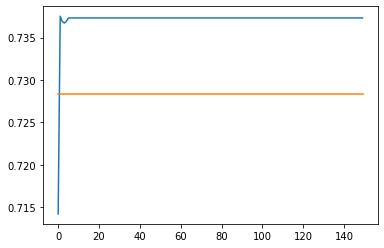

In [46]:
plt.plot(lst3)
plt.plot(lst4)
plt.show()

In [47]:
df.drop("customerID",axis="columns",inplace=True)

In [48]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [49]:
df.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [50]:
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

In [51]:
pd.to_numeric(df.TotalCharges)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [53]:
pd.to_numeric(df.TotalCharges,errors="coerce")
pd.to_numeric(df.TotalCharges,errors="coerce").isnull()
df[pd.to_numeric(df.TotalCharges,errors="coerce").isnull()]
df[pd.to_numeric(df.TotalCharges,errors="coerce").isnull()].shape

(11, 20)

In [54]:
df.iloc[6754]
df.iloc[6754]["TotalCharges"]
df1=df[df.TotalCharges!=' ']

In [55]:
df1.TotalCharges=pd.to_numeric(df1.TotalCharges)

In [56]:
df1.TotalCharges.dtypes

dtype('float64')

In [57]:
def print_unique_col_values(df):
    for column in df:
        if df[column].dtypes=='object':
            print(f'{column} : {df[column].unique()}')

In [58]:
print_unique_col_values(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [59]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

In [60]:
print_unique_col_values(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [61]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup'
                ,'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling',
                'Churn']
for col in  yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

In [62]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [63]:
df1['gender'].replace({'Female': 1,'Male': 0},inplace=True)

In [64]:
df1['gender'].unique()
df2=pd.get_dummies(data=df1,columns=['InternetService','Contract','PaymentMethod'])

In [65]:
df2.sample(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2016,1,0,0,0,10,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
117,1,0,1,1,10,1,1,1,0,0,...,0,1,0,1,0,0,0,0,1,0
1685,0,1,1,0,27,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
3399,1,0,0,0,42,1,1,0,0,1,...,1,0,0,0,0,1,0,1,0,0


In [66]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

In [68]:
scaler=MinMaxScaler()

In [69]:
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [70]:
df2.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1171,0,0,1,0,0.833333,1,0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
92,0,0,1,1,0.916667,1,1,1,0,1,...,1,0,0,0,0,1,0,0,0,1
504,0,0,0,1,0.958333,1,1,1,1,1,...,1,0,0,0,0,1,0,1,0,0


In [71]:
for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: 

In [72]:
x = df2.drop('Churn',axis='columns')
y = df2['Churn']

In [73]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)

In [74]:
x_train.shape

(5634, 26)

In [75]:
x_test.shape

(1409, 26)

In [76]:
len(x_train.columns)

26

In [77]:
model = Sequential()
model.add(Dense(12, input_dim=26, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [78]:
model.fit(x_train,y_train,epochs=150,validation_data=(x_test,y_test))

Epoch 1/150
177/177 [==============================] - 1s 2ms/step - loss: nan - accuracy: 0.7302 - val_loss: nan - val_accuracy: 0.7260
Epoch 2/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 3/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 4/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 5/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 6/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 7/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 8/150
177/177 [====================

177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 61/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 62/150
177/177 [==============================] - 0s 1ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 63/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 64/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 65/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 66/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 67/150
177/177 [=========================

177/177 [==============================] - 0s 1ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 120/150
177/177 [==============================] - 0s 1ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 121/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 122/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 123/150
177/177 [==============================] - 0s 2ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 124/150
177/177 [==============================] - 0s 1ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 125/150
177/177 [==============================] - 0s 3ms/step - loss: nan - accuracy: 0.7368 - val_loss: nan - val_accuracy: 0.7260
Epoch 126/150
177/177 [==================

In [79]:
np.mean(model.history.history['accuracy'])

0.7367329279581706

In [80]:
lst5=model.history.history["accuracy"]
lst6=model.history.history["val_accuracy"]

In [81]:
y_pred = model.predict(x_test)

45/45 [==============================] - 0s 975us/step


In [82]:
y_pred=np.where(y_pred>0.5,1,0)

In [83]:
confusion_matrix(y_test,y_pred)

array([[1023,    0],
       [ 386,    0]], dtype=int64)

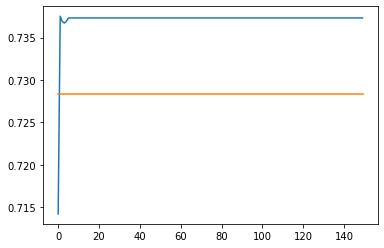

In [84]:
plt.plot(lst3)
plt.plot(lst4)
plt.show()